In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

11-Jun-26 12:00:38 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [2]:
font_path = "/home/z3536241/Fonts/arial.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

plt.rcParams['svg.fonttype'] = 'none'

## load layout files for multiple experiments

In [3]:
dir_path = "/home/z3536241/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/ARMC5mAC/"

Experiment1Layout = pd.read_csv(dir_path + "250128_ARMC5mAC_TotalPolII/METADATA/250128_ARMC5mAC_TotalPolII.csv")
Experiment2Layout = pd.read_csv(dir_path + "250203_ARMC5mAC_TotalPolII/METADATA/250203_ARMC5mAC_TotalPolII.csv")
Experiment3Layout = pd.read_csv(dir_path + "250210_ARMC5mAC_PhosphoPolII/METADATA/250210_ARMC5mAC_PhosphoPolII.csv")
Experiment4Layout = pd.read_csv(dir_path + "250505_ARMC5mAC_PhosphoPolII/METADATA/250505_ARMC5mAC_PhosphoPolII.csv")
Experiment5Layout = pd.read_csv(dir_path + "260119_ARMC5mAC_TotalPhospho/METADATA/260119_ARMC5mAC_TotalPhospho.csv")
Experiment6Layout = pd.read_csv(dir_path + "260127_ARMC5mAC_PhosphoEU/METADATA/260127_ARMC5mAC_PhosphoEU.csv")

## load quantification files and assemble into dataframes

In [4]:
dir_path = "/srv/scratch/berrylab/z3536241/NikonSpinningDisk/"

Experiment1_Quantification_Directory_Cycle1 = Path(dir_path + "250128_ARMC5mAC_TotalPolII/20250203_154917_500/QUANTIFICATION/")
Experiment1_Quantification_Directory_Cycle2 = Path(dir_path + "250128_ARMC5mAC_TotalPolII/20250206_212015_735/QUANTIFICATION/")

Experiment2_Quantification_Directory_Cycle1 = Path(dir_path + "250203_ARMC5mAC_TotalPolII/20250207_215215_806/QUANTIFICATION/")
Experiment2_Quantification_Directory_Cycle2 = Path(dir_path + "250203_ARMC5mAC_TotalPolII/20250210_170713_881/QUANTIFICATION/")

Experiment3_Quantification_Directory_Cycle1 = Path(dir_path + "250210_ARMC5mAC_PhosphoPolII/20250218_143200_062/QUANTIFICATION/")

Experiment4_Quantification_Directory_Cycle1 = Path(dir_path + "250505_ARMC5mAC_PhosphoPolII/20250509_142955_544/QUANTIFICATION/")

Experiment5_Quantification_Directory_Cycle1 = Path(dir_path + "260119_ARMC5mAC_TotalPhospho/20260123_205850_903/QUANTIFICATION/")

Experiment6_Quantification_Directory_Cycle1 = Path(dir_path + "260127_ARMC5mAC_PhosphoEU/20260202_172318_376/QUANTIFICATION/")
Experiment6_Quantification_Directory_Cycle2 = Path(dir_path + "260127_ARMC5mAC_PhosphoEU/20260203_171323_021/QUANTIFICATION/")

Experiment1_Cycle1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle1 / "*.csv"))
Experiment1_Cycle2_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory_Cycle2 / "*.csv"))

Experiment2_Cycle1_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle1 / "*.csv"))
Experiment2_Cycle2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory_Cycle2 / "*.csv"))

Experiment3_Cycle1_Quantification_Files = glob.glob(str(Experiment3_Quantification_Directory_Cycle1 / "*.csv"))
Experiment4_Cycle1_Quantification_Files = glob.glob(str(Experiment4_Quantification_Directory_Cycle1 / "*.csv"))
Experiment5_Cycle1_Quantification_Files = glob.glob(str(Experiment5_Quantification_Directory_Cycle1 / "*.csv"))

Experiment6_Cycle1_Quantification_Files = glob.glob(str(Experiment6_Quantification_Directory_Cycle1 / "*.csv"))
Experiment6_Cycle2_Quantification_Files = glob.glob(str(Experiment6_Quantification_Directory_Cycle2 / "*.csv"))



[len(i) for i in [Experiment1_Cycle1_Quantification_Files, 
                  Experiment1_Cycle2_Quantification_Files, 
                  Experiment2_Cycle1_Quantification_Files, 
                  Experiment2_Cycle2_Quantification_Files, 
                  Experiment3_Cycle1_Quantification_Files, 
                  Experiment4_Cycle1_Quantification_Files, 
                  Experiment5_Cycle1_Quantification_Files,
                  Experiment6_Cycle1_Quantification_Files, 
                  Experiment6_Cycle2_Quantification_Files, 
                  ]]

[960, 939, 960, 927, 915, 960, 960, 960, 2160]

### experiment 1

In [5]:
qdfs = list()


for f in tqdm(Experiment1_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle1 = pd.DataFrame({
    "WELL" : Experiment1_Cycle1_PerCell['well'],
    "IF_561_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_Cycle1_PerCell['Nuclei_area']
})

100%|██████████| 960/960 [00:20<00:00, 47.54it/s]


In [6]:
qdfs = list()


for f in tqdm(Experiment1_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle2 = pd.DataFrame({
    "WELL" : Experiment1_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment1_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment1_Cycle2_PerCell['Nuclei_area']
})

100%|██████████| 939/939 [00:19<00:00, 48.50it/s]


### experiment 2

In [7]:
qdfs = list()


for f in tqdm(Experiment2_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle1_PerCell['fov'] = fovs

100%|██████████| 960/960 [00:18<00:00, 50.61it/s]


In [8]:
Intensities_Experiment2_Cycle1 = pd.DataFrame({
    "WELL" : Experiment2_Cycle1_PerCell['well'],
    "IF_561_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_Cycle1_PerCell['Nuclei_area']
})

In [9]:
qdfs = list()


for f in tqdm(Experiment2_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle2 = pd.DataFrame({
    "WELL" : Experiment2_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment2_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "NucleusArea2" : Experiment2_Cycle2_PerCell['Nuclei_area']
})

100%|██████████| 927/927 [00:17<00:00, 51.85it/s]


### experiment 3

In [10]:
qdfs = list()


for f in tqdm(Experiment3_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment3_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment3_Cycle1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment3_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment3_Cycle1_PerCell['fov'] = fovs

100%|██████████| 915/915 [00:18<00:00, 50.61it/s]


In [11]:
Intensities_Experiment3_Cycle1 = pd.DataFrame({
    "WELL" : Experiment3_Cycle1_PerCell['well'],
    "Alexa647_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_647'],
    "GFP_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment3_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment3_Cycle1_PerCell['Nuclei_area']
})

### experiment 4

In [12]:
qdfs = list()

for f in tqdm(Experiment4_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment4_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment4_Cycle1_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment4_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment4_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment4_Cycle1 = pd.DataFrame({
    "WELL" : Experiment4_Cycle1_PerCell['well'],
    "Alexa647_Intensity" : Experiment4_Cycle1_PerCell['Nuclei_intensity_mean_647'],
    "GFP_Intensity" : Experiment4_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment4_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment4_Cycle1_PerCell['Nuclei_area']
})

100%|██████████| 960/960 [00:39<00:00, 24.12it/s]


### experiment 5

In [13]:
qdfs = list()

for f in tqdm(Experiment5_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment5_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment5_Cycle1_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment5_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment5_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment5_Cycle1 = pd.DataFrame({
    "WELL" : Experiment5_Cycle1_PerCell['well'],
    "Alexa647_Intensity" : Experiment5_Cycle1_PerCell['Nuclei_intensity_mean_640'],
    "GFP_Intensity" : Experiment5_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment5_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment5_Cycle1_PerCell['Nuclei_area']
})

100%|██████████| 960/960 [00:21<00:00, 44.34it/s]


### experiment 6

In [14]:
qdfs = list()

for f in tqdm(Experiment6_Cycle1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment6_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)
files = Experiment6_Cycle1_PerCell['file'].tolist()

wellnames = [f[4:7] for f in files]
Experiment6_Cycle1_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment6_Cycle1_PerCell['fov'] = fovs

100%|██████████| 960/960 [00:18<00:00, 51.13it/s]


In [15]:
Intensities_Experiment6_Cycle1 = pd.DataFrame({
    "WELL" : Experiment6_Cycle1_PerCell['well'],
    "IF_561_Intensity" : Experiment6_Cycle1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : Experiment6_Cycle1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment6_Cycle1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment6_Cycle1_PerCell['Nuclei_area']
})

In [16]:
qdfs = list()

for f in tqdm(Experiment6_Cycle2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment6_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)
files = Experiment6_Cycle2_PerCell['file'].tolist()
wellnames = [f[4:7] for f in files]
Experiment6_Cycle2_PerCell['well'] = wellnames
fovs = [f[39:43] for f in files]
Experiment6_Cycle2_PerCell['fov'] = fovs
Intensities_Experiment6_Cycle2 = pd.DataFrame({
    "WELL" : Experiment6_Cycle2_PerCell['well'],
    "Alexa647_Intensity" : Experiment6_Cycle2_PerCell['Nuclei_intensity_mean_647'],
    "DAPI_Intensity" : Experiment6_Cycle2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea2" : Experiment6_Cycle2_PerCell['Nuclei_area']
})

100%|██████████| 2160/2160 [00:39<00:00, 54.12it/s]


## average by individual wells, add cell counts, and merge with layouts,

In [17]:
CountsByWell1 = Intensities_Experiment1_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1_Cycle1 = Intensities_Experiment1_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1_Cycle1 = IntensitiesByWell_Experiment1_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment1_Cycle2 = Intensities_Experiment1_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1_Cycle1.merge(IntensitiesByWell_Experiment1_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment1['EXPERIMENT'] = '241026_mACmChPOLR2A_ActivePolII'

In [18]:
CountsByWell2 = Intensities_Experiment2_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2_Cycle1 = Intensities_Experiment2_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2_Cycle1 = IntensitiesByWell_Experiment2_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment2_Cycle2 = Intensities_Experiment2_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2_Cycle1.merge(IntensitiesByWell_Experiment2_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250203_mACmChPOLR2A_ActivePolII'

In [19]:
CountsByWell3 = Intensities_Experiment3_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell3.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment3_Cycle1 = Intensities_Experiment3_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment3Layout, how = 'left')
IntensitiesByWell_Experiment3_Cycle1 = IntensitiesByWell_Experiment3_Cycle1.merge(CountsByWell3)

IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3_Cycle1
IntensitiesByWell_Experiment3['EXPERIMENT'] = '250210_mACmChPOLR2A_PhosphoPolII'

In [20]:
CountsByWell4 = Intensities_Experiment4_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell4.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment4_Cycle1 = Intensities_Experiment4_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment4Layout, how = 'left')
IntensitiesByWell_Experiment4_Cycle1 = IntensitiesByWell_Experiment4_Cycle1.merge(CountsByWell4)

IntensitiesByWell_Experiment4 = IntensitiesByWell_Experiment4_Cycle1
IntensitiesByWell_Experiment4['EXPERIMENT'] = '250505_mACmChPOLR2A_PhosphoPolII'

In [21]:
CountsByWell5 = Intensities_Experiment5_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell5.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment5_Cycle1 = Intensities_Experiment5_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment5Layout, how = 'left')
IntensitiesByWell_Experiment5_Cycle1 = IntensitiesByWell_Experiment5_Cycle1.merge(CountsByWell5)
IntensitiesByWell_Experiment5 = IntensitiesByWell_Experiment5_Cycle1
IntensitiesByWell_Experiment5['EXPERIMENT'] = '260119_mACmChPOLR2A_TotalPhospho'

In [22]:
CountsByWell6 = Intensities_Experiment6_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell6.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment6_Cycle1 = Intensities_Experiment6_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment6Layout, how = 'left')
IntensitiesByWell_Experiment6_Cycle1 = IntensitiesByWell_Experiment6_Cycle1.merge(CountsByWell6)
IntensitiesByWell_Experiment6_Cycle2 = Intensities_Experiment6_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment6 = IntensitiesByWell_Experiment6_Cycle1.merge(IntensitiesByWell_Experiment6_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment6['EXPERIMENT'] = '260127_mACmChPOLR2A_PhosphoEU'

## examine raw data per experiment

In [23]:
IntensitiesByWell_Experiment1.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
       'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object)

In [24]:
IntensitiesByWell_Experiment1.DRUG.unique()

array(['No addition', 'Vehicle', '10 µM 5PhIAA'], dtype=object)

In [25]:
cell_relabel = dict(zip(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1', 'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'],
                        ['OsTIRF74G', 'ARMC5mAC 5A1', 'ARMC5mAC Clone 5F9']))

In [26]:
cell_relabel_order = ['OsTIRF74G', 'ARMC5mAC 5A1', 'ARMC5mAC Clone 5F9']

### experiment 1

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/3280853971.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)


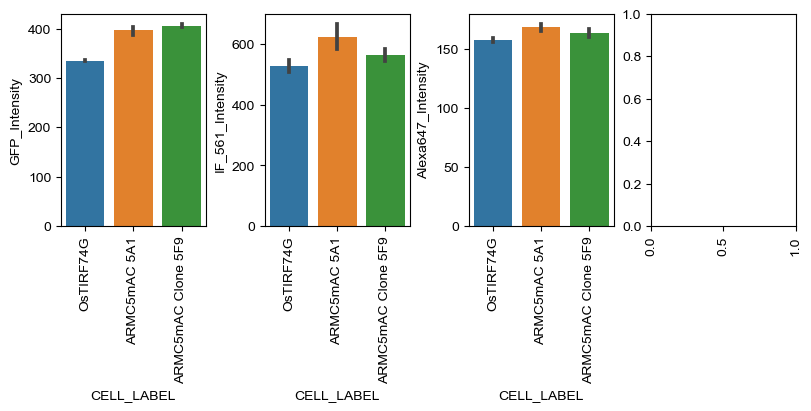

In [27]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment1_Baseline = IntensitiesByWell_Experiment1.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment1_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment1_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment1_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'IF_561_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment1_Baseline.query('EU == "EU 1 mM, 30 mins"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

### experiment 2

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/1813116177.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)


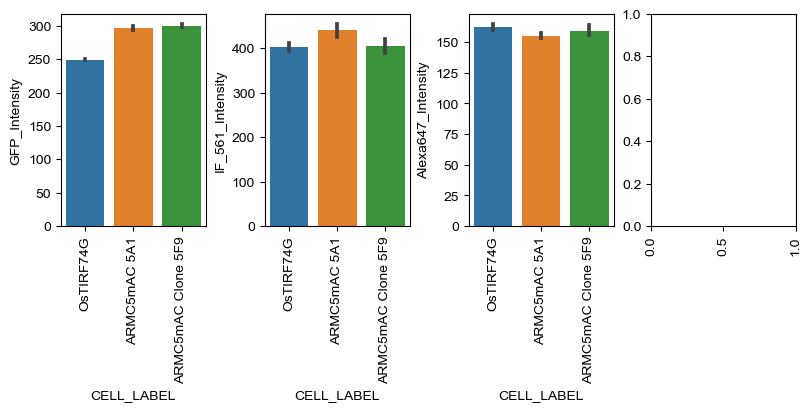

In [28]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment2_Baseline = IntensitiesByWell_Experiment2.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment2_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment2_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment2_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'IF_561_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment2_Baseline.query('EU == "EU 1 mM, 30 mins"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

### experiment 3

In [29]:
IntensitiesByWell_Experiment3.PRIMARY.unique()

array(['pSer2 Pol II 3E10', 'pSer5 Pol II 3E8', 'No primary'],
      dtype=object)

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/877051357.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)


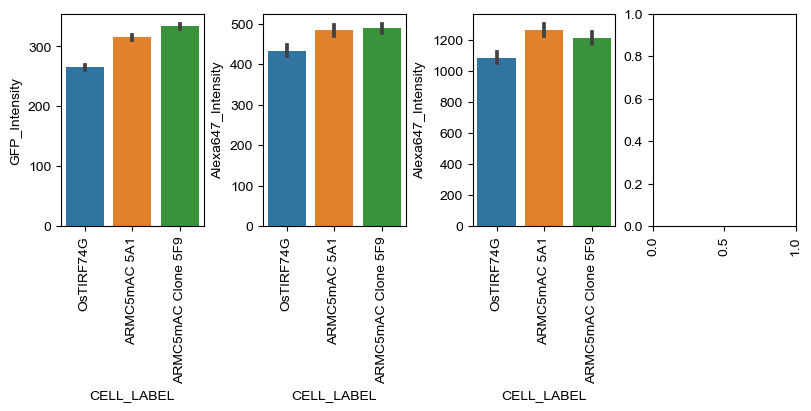

In [30]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment3_Baseline = IntensitiesByWell_Experiment3.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment3_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment3_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment3_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "pSer2 Pol II 3E10"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment3_Baseline.query('PRIMARY == "pSer5 Pol II 3E8"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

### experiment 4

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/3150080002.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment4_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment4_Baseline['CELL'].map(cell_relabel)


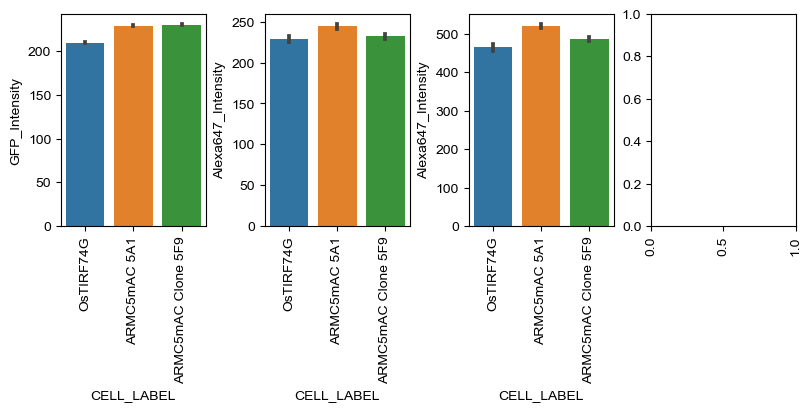

In [31]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment4_Baseline = IntensitiesByWell_Experiment4.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment4_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment4_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment4_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment4_Baseline.query('PRIMARY == "pSer2 Pol II 3E10"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment4_Baseline.query('PRIMARY == "pSer5 Pol II 3E8"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])

for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

### experiment 5

In [32]:
IntensitiesByWell_Experiment5.columns

Index(['WELL', 'Alexa647_Intensity', 'GFP_Intensity', 'DAPI_Intensity',
       'NucleusArea', 'CELL', 'DRUG', 'DRUG TIME HOURS', 'PRIMARY',
       'SECONDARY', 'TotalNumberCells', 'EXPERIMENT'],
      dtype='object')

In [33]:
IntensitiesByWell_Experiment5.PRIMARY.unique()

array(['Total Pol II F12', 'pSer2 Pol II 3E10'], dtype=object)

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/976524393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment5_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment5_Baseline['CELL'].map(cell_relabel)


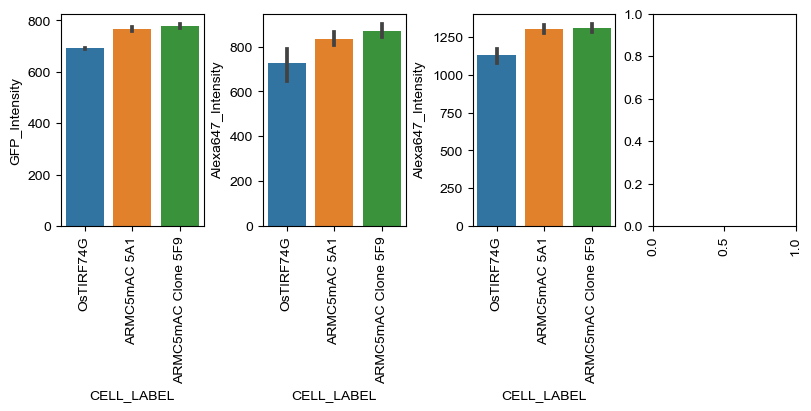

In [34]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')



IntensitiesByWell_Experiment5_Baseline = IntensitiesByWell_Experiment5.query('DRUG == "No addition" | DRUG == "Vehicle"')

IntensitiesByWell_Experiment5_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment5_Baseline['CELL'].map(cell_relabel)



sns.barplot(IntensitiesByWell_Experiment5_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])



sns.barplot(IntensitiesByWell_Experiment5_Baseline.query('PRIMARY == "Total Pol II F12"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[1])



sns.barplot(IntensitiesByWell_Experiment5_Baseline.query('PRIMARY == "pSer2 Pol II 3E10"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])



for i in range(4):

    a[i].tick_params(axis = 'x', labelrotation = 90)

### experiment 6

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/252323599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell_Experiment6_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment6_Baseline['CELL'].map(cell_relabel)


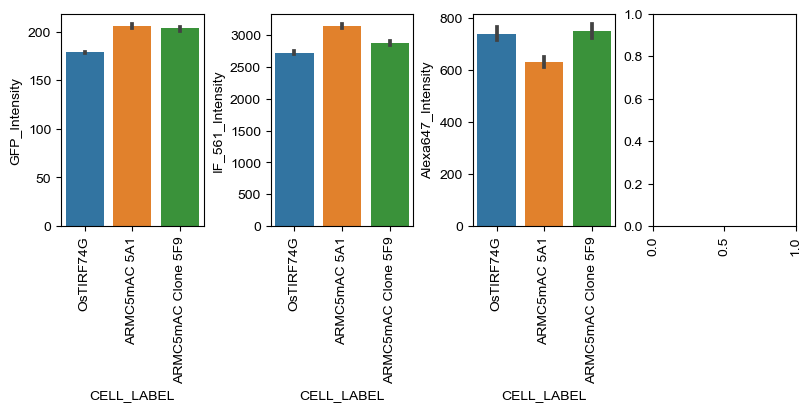

In [35]:
f, a = plt.subplots(ncols = 4, figsize = (8,4), layout = 'constrained')

IntensitiesByWell_Experiment6_Baseline = IntensitiesByWell_Experiment6.query('DRUG == "No addition" | DRUG == "Vehicle"')
IntensitiesByWell_Experiment6_Baseline['CELL_LABEL'] = IntensitiesByWell_Experiment6_Baseline['CELL'].map(cell_relabel)

sns.barplot(IntensitiesByWell_Experiment6_Baseline,
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'GFP_Intensity',
            ax = a[0])

sns.barplot(IntensitiesByWell_Experiment6_Baseline.query('PRIMARY == "pSer5 Pol II 3E8"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'IF_561_Intensity',
            ax = a[1])

sns.barplot(IntensitiesByWell_Experiment6_Baseline.query('EU == "EU 1 mM, 30 mins"'),
            x = 'CELL_LABEL', order = cell_relabel_order,
            y = 'Alexa647_Intensity',
            ax = a[2])


for i in range(4):
    a[i].tick_params(axis = 'x', labelrotation = 90)

## background subtract and normalise within experiments

### GFP

In [36]:
[x.CELL.unique() for x in [IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2, IntensitiesByWell_Experiment3, IntensitiesByWell_Experiment4, IntensitiesByWell_Experiment5]]

[array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5F9',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5A1'], dtype=object),
 array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G ARMC5mAC Clone 5A1',
        'HCT116 OsTIRF74G ARMC5mAC Clone 5F9'], dtype=object)]

In [37]:
# Background subtraction using HCT116 OsTIRF74G cells

E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E3_GFP_Zero = IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E4_GFP_Zero = IntensitiesByWell_Experiment4.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E5_GFP_Zero = IntensitiesByWell_Experiment5.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E6_GFP_Zero = IntensitiesByWell_Experiment6.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_Intensity'] - E2_GFP_Zero
IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment3['GFP_Intensity'] - E3_GFP_Zero
IntensitiesByWell_Experiment4['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment4['GFP_Intensity'] - E4_GFP_Zero
IntensitiesByWell_Experiment5['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment5['GFP_Intensity'] - E5_GFP_Zero
IntensitiesByWell_Experiment6['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment6['GFP_Intensity'] - E6_GFP_Zero

# Normalization to Vehicle-treated HCT116 OsTIRF74G ARMC5mAC Clone 5A1

E1_GFP_NV = IntensitiesByWell_Experiment1.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E2_GFP_NV = IntensitiesByWell_Experiment2.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E3_GFP_NV = IntensitiesByWell_Experiment3.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E4_GFP_NV = IntensitiesByWell_Experiment4.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E5_GFP_NV = IntensitiesByWell_Experiment5.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

E6_GFP_NV = IntensitiesByWell_Experiment6.query(
    'CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1" & DRUG == "Vehicle"'
).GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV
IntensitiesByWell_Experiment3['GFP_Intensity_FC'] = IntensitiesByWell_Experiment3['GFP_Intensity_BGS'] / E3_GFP_NV
IntensitiesByWell_Experiment4['GFP_Intensity_FC'] = IntensitiesByWell_Experiment4['GFP_Intensity_BGS'] / E4_GFP_NV
IntensitiesByWell_Experiment5['GFP_Intensity_FC'] = IntensitiesByWell_Experiment5['GFP_Intensity_BGS'] / E5_GFP_NV
IntensitiesByWell_Experiment6['GFP_Intensity_FC'] = IntensitiesByWell_Experiment6['GFP_Intensity_BGS'] / E6_GFP_NV

In [38]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, 
                               IntensitiesByWell_Experiment2, 
                               IntensitiesByWell_Experiment3,
                               IntensitiesByWell_Experiment4, 
                               IntensitiesByWell_Experiment5, 
                               IntensitiesByWell_Experiment6])
                               

In [39]:
IntensitiesByWell.DRUG.unique()

array(['No addition', 'Vehicle', '10 µM 5PhIAA'], dtype=object)

In [40]:
IntensitiesByWell['TIME_HOURS'] = IntensitiesByWell['DRUG TIME HOURS']

In [41]:
# fold untreated and vehicle wells into 0 timepoint

def time_in_auxin(d,t):
    if d == "10 µM 5PhIAA":
        return t
    elif d == "Vehicle":
        return 0
    elif d == "No addition":
        return 0

In [42]:
IntensitiesByWell['TIME_IN_AUXIN_HRS'] = IntensitiesByWell.apply(lambda x: time_in_auxin(x.DRUG,x.TIME_HOURS), axis = 1).astype(float)

In [43]:
[x['DRUG TIME HOURS'].unique() for x in [IntensitiesByWell_Experiment1, 
                               IntensitiesByWell_Experiment2, 
                               IntensitiesByWell_Experiment3,
                               IntensitiesByWell_Experiment4, 
                               IntensitiesByWell_Experiment5, 
                               IntensitiesByWell_Experiment6]]

[array(['No addition', '72', '48', '24', '8', '2'], dtype=object),
 array(['No addition', '2', '8', '24', '48', '72'], dtype=object),
 array([24. , 48. ,  8. ,  2. ,  0.5]),
 array([48. ,  0.5,  2. ,  8. , 24. ]),
 array([24. , 48. ,  8. ,  2. ,  0.5]),
 array(['No addition', '2', '8', '24', '48'], dtype=object)]

In [44]:
# filter for timepoints common to all experiments

IntensitiesByWell = IntensitiesByWell.query('TIME_IN_AUXIN_HRS in [0, 2, 8, 24, 48]')

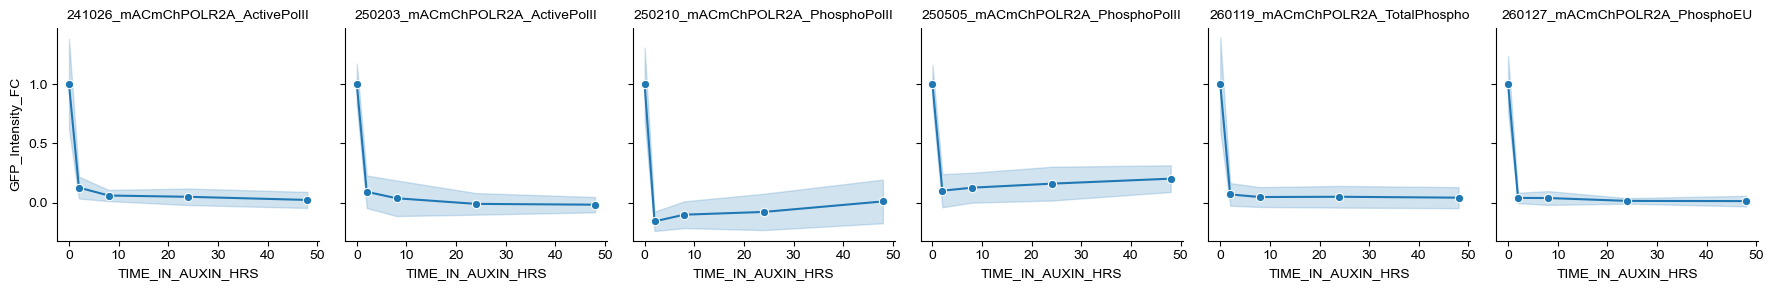

In [45]:
g = sns.FacetGrid(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN_HRS',
                y = 'GFP_Intensity_FC',
                marker = 'o',
                errorbar = 'sd')

g.set_titles(template="{col_name}")

### Total Pol II (F12) Immunofluorescence

In [46]:
 IntensitiesByWell_Experiment2.columns

Index(['WELL', 'IF_561_Intensity', 'GFP_Intensity', 'DAPI_Intensity',
       'NucleusArea', 'CELL', 'EU', 'DRUG', 'DRUG TIME HOURS', 'PRIMARY',
       'SECONDARY', 'TotalNumberCells', 'Alexa647_Intensity', 'NucleusArea2',
       'EXPERIMENT', 'GFP_Intensity_BGS', 'GFP_Intensity_FC'],
      dtype='object')

In [47]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_561_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa647"').IF_561_Intensity.mean()
E5_Mouse_Zero = IntensitiesByWell_Experiment5.query('WELL == "N12"').Alexa647_Intensity.mean()

Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II F12"')
Total_IntensitiesByWell_Experiment5 = IntensitiesByWell_Experiment5.query('PRIMARY == "Total Pol II F12"')

Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity'] - E2_Mouse_Zero
Total_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment5['Alexa647_Intensity'] - E5_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E5_Total_NV = Total_IntensitiesByWell_Experiment5.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] / E2_Total_NV
Total_IntensitiesByWell_Experiment5['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] / E5_Total_NV

Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, 
                               Total_IntensitiesByWell_Experiment2, 
                               Total_IntensitiesByWell_Experiment5])
                               

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/1971602163.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_561_Intensity'] - E1_Mouse_Zero
/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/1971602163.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_561_Intensity'] - E2_Mouse_Zero

### pSer2 Pol II (3E10) Immunofluorescence

In [48]:
IntensitiesByWell_Experiment3.PRIMARY.unique(), IntensitiesByWell_Experiment4.PRIMARY.unique(), IntensitiesByWell_Experiment5.PRIMARY.unique()

(array(['pSer2 Pol II 3E10', 'pSer5 Pol II 3E8', 'No primary'],
       dtype=object),
 array(['pSer5 Pol II 3E8', 'pSer2 Pol II 3E10', 'No primary'],
       dtype=object),
 array(['Total Pol II F12', 'pSer2 Pol II 3E10'], dtype=object))

In [49]:
E3_Rat_Zero = IntensitiesByWell_Experiment3.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E4_Rat_Zero = IntensitiesByWell_Experiment4.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-rat Alexa647"').Alexa647_Intensity.mean()
E5_Rat_Zero = IntensitiesByWell_Experiment5.query('WELL == "N12"').Alexa647_Intensity.mean()

pSer2_IntensitiesByWell_Experiment3 = IntensitiesByWell_Experiment3.query('PRIMARY == "pSer2 Pol II 3E10"')
pSer2_IntensitiesByWell_Experiment4 = IntensitiesByWell_Experiment4.query('PRIMARY == "pSer2 Pol II 3E10"')
pSer2_IntensitiesByWell_Experiment5 = IntensitiesByWell_Experiment5.query('PRIMARY == "pSer2 Pol II 3E10"')

pSer2_IntensitiesByWell_Experiment3['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Rat_Zero
pSer2_IntensitiesByWell_Experiment4['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment4['Alexa647_Intensity'] - E4_Rat_Zero
pSer2_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment5['Alexa647_Intensity'] - E5_Rat_Zero

E3_pSer2_NV = pSer2_IntensitiesByWell_Experiment3.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E4_pSer2_NV = pSer2_IntensitiesByWell_Experiment4.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E5_pSer2_NV = pSer2_IntensitiesByWell_Experiment5.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()

pSer2_IntensitiesByWell_Experiment3['IF_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment3['IF_Intensity_BGS'] / E3_pSer2_NV
pSer2_IntensitiesByWell_Experiment4['IF_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment4['IF_Intensity_BGS'] / E4_pSer2_NV
pSer2_IntensitiesByWell_Experiment5['IF_Intensity_FC'] = pSer2_IntensitiesByWell_Experiment5['IF_Intensity_BGS'] / E5_pSer2_NV

pSer2_IntensitiesByWell = pd.concat([pSer2_IntensitiesByWell_Experiment3, pSer2_IntensitiesByWell_Experiment4, pSer2_IntensitiesByWell_Experiment5])

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/638105298.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pSer2_IntensitiesByWell_Experiment3['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment3['Alexa647_Intensity'] - E3_Rat_Zero
/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/638105298.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pSer2_IntensitiesByWell_Experiment4['IF_Intensity_BGS'] = pSer2_IntensitiesByWell_Experiment4['Alexa647_Intensity'] - E4_Rat_Zero
/

### EU incorporation

In [50]:
IntensitiesByWell_Experiment1.EU.unique(), IntensitiesByWell_Experiment2.EU.unique(), IntensitiesByWell_Experiment6.EU.unique()

(array(['No addition', 'EU 1 mM, 30 mins'], dtype=object),
 array(['No addition', 'EU 1 mM, 30 mins'], dtype=object),
 array(['No addition', 'EU 1 mM, 30 mins'], dtype=object))

In [51]:
E1_EU_Zero = IntensitiesByWell_Experiment1.query('EU == "No addition"').Alexa647_Intensity.mean()
E2_EU_Zero = IntensitiesByWell_Experiment2.query('EU == "No addition"').Alexa647_Intensity.mean()
E6_EU_Zero = IntensitiesByWell_Experiment6.query('EU == "No addition"').Alexa647_Intensity.mean()

EU_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment6 = IntensitiesByWell_Experiment6.query('EU == "EU 1 mM, 30 mins"')


EU_IntensitiesByWell_Experiment1['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_EU_Zero
EU_IntensitiesByWell_Experiment2['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E1_EU_Zero
EU_IntensitiesByWell_Experiment6['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment6['Alexa647_Intensity'] - E1_EU_Zero

E1_EU_NV = EU_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').EU_Intensity_BGS.mean()
E2_EU_NV = EU_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').EU_Intensity_BGS.mean()
E6_EU_NV = EU_IntensitiesByWell_Experiment6.query('CELL == "HCT116 OsTIRF74G" & DRUG == "Vehicle"').EU_Intensity_BGS.mean()

EU_IntensitiesByWell_Experiment1['EU_Intensity_FC'] = EU_IntensitiesByWell_Experiment1['EU_Intensity_BGS'] / E1_EU_NV
EU_IntensitiesByWell_Experiment2['EU_Intensity_FC'] = EU_IntensitiesByWell_Experiment2['EU_Intensity_BGS'] / E2_EU_NV
EU_IntensitiesByWell_Experiment6['EU_Intensity_FC'] = EU_IntensitiesByWell_Experiment6['EU_Intensity_BGS'] / E6_EU_NV

EU_IntensitiesByWell = pd.concat([EU_IntensitiesByWell_Experiment1, EU_IntensitiesByWell_Experiment2, EU_IntensitiesByWell_Experiment6])

/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/3365191094.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment1['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment1['Alexa647_Intensity'] - E1_EU_Zero
/scratch/pbs.8258278.kman.restech.unsw.edu.au/ipykernel_130944/3365191094.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment2['EU_Intensity_BGS'] = EU_IntensitiesByWell_Experiment2['Alexa647_Intensity'] - E1_EU_Zero
/scratch/pbs

## Baseline plots for manuscript supplemental

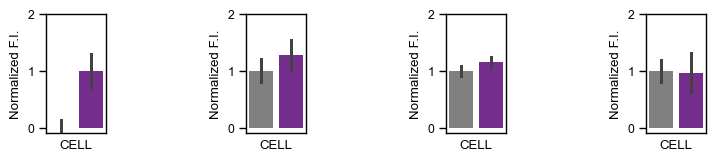

In [68]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 4, figsize = (8, 1.5), layout = 'constrained')

cell_order = ["HCT116 OsTIRF74G", "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"]

g = sns.barplot(IntensitiesByWell.query('CELL in ["HCT116 OsTIRF74G", "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"] & DRUG == "Vehicle"'), 
             x = 'CELL', order = cell_order,
             y = 'GFP_Intensity_FC',
            errorbar = 'sd',
            ax = a[0],
            hue = 'CELL', hue_order = cell_order,
                dodge = False,
            palette = sns.color_palette(['grey', 'xkcd:purple']))
g.get_legend().remove()

g = sns.barplot(Total_IntensitiesByWell.query('CELL in ["HCT116 OsTIRF74G", "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"] & DRUG == "Vehicle"'), 
             x = 'CELL',  order = cell_order,
             y = 'IF_Intensity_FC',
            errorbar = 'sd',
            ax = a[1],
            hue = 'CELL', hue_order = cell_order,
                dodge = False,
            palette = sns.color_palette(['grey', 'xkcd:purple']))
g.get_legend().remove()

g = sns.barplot(pSer2_IntensitiesByWell.query('CELL in ["HCT116 OsTIRF74G", "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"] & DRUG == "Vehicle"'), 
             x = 'CELL',  order = cell_order,
             y = 'IF_Intensity_FC',
            errorbar = 'sd',
            ax = a[2],
            hue = 'CELL', hue_order = cell_order,
                dodge = False,
            palette = sns.color_palette(['grey', 'xkcd:purple']))
g.get_legend().remove()

g = sns.barplot(EU_IntensitiesByWell.query('CELL in ["HCT116 OsTIRF74G", "HCT116 OsTIRF74G ARMC5mAC Clone 5A1"] & DRUG == "Vehicle"'), 
             x = 'CELL',  order = cell_order,
             y = 'EU_Intensity_FC',
            errorbar = 'sd',
            ax = a[3],
            hue = 'CELL', hue_order = cell_order,
                dodge = False,
            palette = sns.color_palette(['grey', 'xkcd:purple']))
g.get_legend().remove()

for i in range(4):
    a[i].set_xticks([])
    a[i].set_box_aspect(2)
    a[i].set_ylim(-0.1,2)
    a[i].set_yticks([0,1,2])
    a[i].set_ylabel('Normalized F.I.')

plt.savefig('OsTIR_vs_ARMC5mAC_GFP_TotalPolII_pSer2PolII_EU_baseline.svg')